# H-003 · Kalman β vs static OLS hedge (trad-z)

Both arms use traditional z entry/exit (`k=2 / 0`). OLS is rolling 252. Kalman is Chan 2-state prior-state KF (`obs_var=1e-3`, `burn_in=30` days, session-scaled on 1H). Pre-registered **δ grid** `{1e-5, 1e-6, 1e-7}` (Chan `δ=1e-4` is diagnostic-only — too fast / white innovations).

Freeze on fold-val Sharpe (max DD / corr to S1 as secondary). ADF / HL / lag-1 autocorr are **not** freeze inputs. Type `HEDGE_STAR` (`"ols"` or `"kalman"`); if Kalman, also type `KALMAN_DELTA_STAR`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    load_universe_c_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
PAIRS_STAR = list(stack["PAIRS_STAR"])
print("stack keys:", sorted(stack))
print("PAIRS_STAR", PAIRS_STAR)


stack keys: ['BAR_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR']
PAIRS_STAR ['1398.HK|0939.HK', '1288.HK|3328.HK', '8306.T|8316.T']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_c_panels(BAR, PAIRS_STAR, root=ROOT)
# Keep OLS columns so the bake-off stays honest even if HEDGE_STAR was already typed.
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 10592 OOS rows 3398


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,2005-09-29,8306.T|8316.T,8306.T,8316.T,794.893020,805.781966,767.670656,789.448547,1782.033531,1879.235357,1717.232234,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-09-30,8306.T|8316.T,8306.T,8316.T,794.893202,833.004519,773.115306,811.226624,1749.632882,1798.233795,1701.031969,1733.432617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-10-03,8306.T|8316.T,8306.T,8316.T,794.893317,800.337791,751.337518,773.115417,1701.032155,1733.432807,1652.431236,1717.232422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005-10-04,8306.T|8316.T,8306.T,8316.T,778.559552,784.004025,751.337190,762.226135,1701.031997,1701.031997,1636.230817,1668.631348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005-10-05,8306.T|8316.T,8306.T,8316.T,767.670608,784.004025,751.337190,762.226135,1636.230866,1652.431132,1594.110033,1608.690308,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach Kalman hedge columns (OLS panel already loaded)


In [3]:
lb = lookbacks_for_bar(BAR)
KALMAN_DELTA_GRID = (1e-4, 1e-5, 1e-6, 1e-7)
CHAN_SANITY_DELTA = 1e-3


def _hedge_diag(panel, label):
    g = panel.groupby("pair_id")
    return pd.DataFrame(
        {
            "median_adf": g["adf_pvalue"].median(),
            "median_hl": g["half_life"].median(),
            "lag1_ac": g["spread"].apply(lambda s: float(s.astype(float).autocorr(lag=1))),
        }
    ).assign(arm=label)


kf_panels = {}
rows = [_hedge_diag(is_panel, "ols")]
for d in (CHAN_SANITY_DELTA,) + KALMAN_DELTA_GRID:
    p = overlay_kalman_hedge(
        is_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        delta=d,
    )
    if d in KALMAN_DELTA_GRID:
        kf_panels[d] = p
    rows.append(_hedge_diag(p, f"kalman_{d:g}"))

diag = pd.concat(rows)
print("ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.")
print("Chan δ=1e-4 is sanity contrast only — not a freeze candidate.")
diag


ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.
Chan δ=1e-4 is sanity contrast only — not a freeze candidate.


,median_adf,median_hl,lag1_ac,arm
pair_id,,,,
1288.HK|3328.HK,3.024222e-01,22.297215,0.979551,ols
1398.HK|0939.HK,1.945797e-01,16.600571,0.971399,ols
8306.T|8316.T,2.316850e-01,15.974046,0.973263,ols
1288.HK|3328.HK,3.492213e-10,1.322155,0.624913,kalman_0.0001
1398.HK|0939.HK,2.329272e-09,1.314515,0.644488,kalman_0.0001
8306.T|8316.T,7.937099e-21,0.388208,0.144215,kalman_0.0001
1288.HK|3328.HK,1.009114e-04,3.595714,0.841152,kalman_1e-05
1398.HK|0939.HK,1.473674e-04,3.635968,0.867788,kalman_1e-05
8306.T|8316.T,3.571932e-14,0.976946,0.472183,kalman_1e-05


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(is_panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2005-09-29,2009-10-13,1050,2009-10-14,2009-10-20,2009-10-21,2013-11-13,1055
1,2,2005-09-29,2013-11-06,2105,2013-11-07,2013-11-13,2013-11-14,2017-12-08,1055
2,3,2005-09-29,2017-12-01,3160,2017-12-04,2017-12-08,2017-12-11,2021-12-31,1055


## 4. Fold-val metrics (validation only)


In [5]:
cfg_ols = config_from_stack(stack, hedge="ols")
parts = [fold_val_metrics(is_panel, folds, {"ols": cfg_ols}, s1_weekly=s1_weekly)]
cfg_kf = config_from_stack(stack, hedge="kalman")
for d, panel in kf_panels.items():
    arm = f"kalman_{d:g}"
    parts.append(fold_val_metrics(panel, folds, {arm: cfg_kf}, s1_weekly=s1_weekly))
fold_df = pd.concat(parts, ignore_index=True)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,ols,1,-0.455536,-0.088606,NaN,1053,38,0.890227,13.573501,13.573501
1,ols,2,-1.100158,-0.172229,-0.049184,1053,53,1.000000,18.064261,18.064261
2,ols,3,-0.927814,-0.144014,-0.068434,1053,53,1.000000,35.216892,35.216892
3,kalman_1e-05,1,-1.321728,-0.183213,NaN,1053,83,0.968484,2.865478,2.865478
4,kalman_1e-05,2,-2.053502,-0.211847,-0.051133,1053,91,1.000000,2.524757,2.524757
5,kalman_1e-05,3,-2.499459,-0.245118,-0.124640,1053,88,1.000000,2.942629,2.942629
6,kalman_1e-06,1,-0.747839,-0.124273,NaN,1053,53,0.968484,7.110838,7.110838
7,kalman_1e-06,2,-1.427734,-0.168089,-0.001761,1053,73,1.000000,5.552357,5.552357
8,kalman_1e-06,3,-1.966452,-0.216259,-0.147723,1053,62,1.000000,7.110580,7.110580
9,kalman_1e-07,1,-0.836638,-0.157231,NaN,1053,42,0.968484,12.331773,12.331773


## 5. Boxplots (do not assign STAR here)


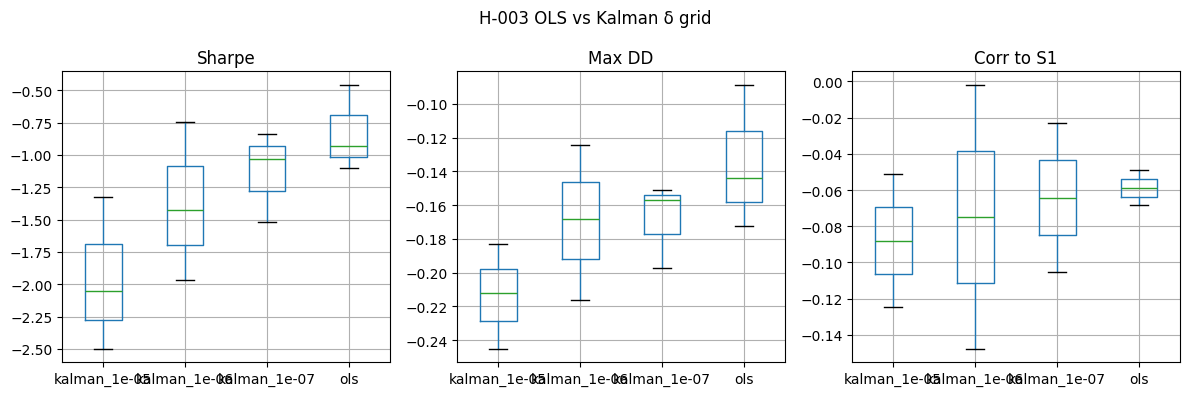

median-Sharpe hint (commentary only): ols


,ann_sharpe,max_drawdown,corr_to_s1
arm,,,
kalman_1e-05,-2.053502,-0.211847,-0.087886
kalman_1e-06,-1.427734,-0.168089,-0.074742
kalman_1e-07,-1.030847,-0.157231,-0.064194
ols,-0.927814,-0.144014,-0.058809


In [6]:
plot_fold_boxplots(fold_df, title="H-003 OLS vs Kalman δ grid")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
fold_df.groupby("arm")[["ann_sharpe", "max_drawdown", "corr_to_s1"]].median()


## 6. Type `HEDGE_STAR` (and `KALMAN_DELTA_STAR` if Kalman) then save


In [8]:
HEDGE_STAR = "ols"  # TODO after fold-val review: "ols" or "kalman"
KALMAN_DELTA_STAR = None  # TODO if Kalman: 1e-5, 1e-6, or 1e-7 (not 1e-4)
require_star("HEDGE_STAR", HEDGE_STAR)
stack["HEDGE_STAR"] = HEDGE_STAR
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    dstar = float(KALMAN_DELTA_STAR)
    if not any(abs(dstar - d) < 1e-12 for d in KALMAN_DELTA_GRID):
        raise ValueError(f"KALMAN_DELTA_STAR must be one of {KALMAN_DELTA_GRID}, got {KALMAN_DELTA_STAR!r}")
    stack["KALMAN_DELTA_STAR"] = dstar
else:
    stack["KALMAN_DELTA_STAR"] = None
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "HEDGE_STAR", HEDGE_STAR, "KALMAN_DELTA_STAR", stack.get("KALMAN_DELTA_STAR"))


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json HEDGE_STAR ols KALMAN_DELTA_STAR None


## 7. Sealed OOS once


In [9]:
require_star("HEDGE_STAR", HEDGE_STAR)
oos_use = oos_panel
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    oos_use = overlay_kalman_hedge(
        oos_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        delta=float(KALMAN_DELTA_STAR),
    )
oos = run_s2_backtest(oos_use, config_from_stack(stack), s1_weekly=s1_weekly)
print(oos.metrics)
arm_label = HEDGE_STAR if HEDGE_STAR == "ols" else f"kalman_{float(KALMAN_DELTA_STAR):g}"
write_tearsheet_pdf(tearsheet_path("H-003", arm_label), oos.returns, title=f"H-003 {arm_label} sealed OOS")


{'ann_sharpe': -1.2886669407717484, 'max_drawdown': -0.2174382893930048, 'n_days': 1198, 'corr_to_s1': 0.10158983340520264}


## 8. Notes for next hyp


H-004 cointegration-break flat rule (`off` | `block_05_flat_10` | `flat_05`). Leave `HEDGE_STAR` and `KALMAN_DELTA_STAR` frozen. If 1h is ever re-opened, Kalman \(Q\) should be \(\approx Q_{\mathrm{day}}/6\) so calendar adaptation matches (do not session-scale \(\delta\) on 1d).
